# Exploración ICS e IPM

Carga de shapefiles desde el repositorio, visualización en mapa y análisis inicial del Índice de Condición Social (ICS) y el Índice de Pobreza Multidimensional (IPM) a nivel de manzana.


In [12]:
# @title 1. Montar Google Drive (opcional, solo en Colab)
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive montado')
else:
    print('Ejecutando localmente')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive montado


In [13]:
# @title 2. Instalar dependencias
!pip install geopandas matplotlib mapclassify pyarrow openpyxl pyogrio -q


In [14]:
# @title 3. Clonar el repositorio (solo si es necesario)
import os
import shutil

REPO_URL = 'https://github.com/j0rg3c45/Pobreza_multidimensional_y_condicion_social.git'
REPO_DIR = 'Pobreza_multidimensional_y_condicion_social'

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}
else:
    %cd {REPO_DIR}
    !git pull
    %cd ..
print('Repositorio listo')


/content/Pobreza_multidimensional_y_condicion_social
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (8/8), done.
remote: Total 11 (delta 7), reused 8 (delta 7), pack-reused 3 (from 1)
Unpacking objects: 100% (11/11), 8.20 MiB | 5.64 MiB/s, done.
From https://github.com/j0rg3c45/Pobreza_multidimensional_y_condicion_social
   2c3bc67..95d981d  main       -> origin/main
Updating 2c3bc67..95d981d
Fast-forward
 indice_Pobreza/data/geojosn_ICS/ics_mzn.geojson    | 31317 ++++++++++---------
 .../notebooks_py/01_exploracion_ics_ipm.ipynb      |    82 +-
 2 files changed, 15724 insertions(+), 15675 deletions(-)
/content
Repositorio listo


In [15]:
# @title 4. Importar librerías
import zipfile
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
from pathlib import Path

print('Librerías importadas')


Librerías importadas


In [16]:
# @title 5. Definir rutas maestros
BASE_DIR = REPO_DIR if os.path.exists(REPO_DIR) else '.'
DATA_DIR = os.path.join(BASE_DIR, 'indice_Pobreza', 'data')
EXCEL_PATH = os.path.join(BASE_DIR, 'IPM - Variables (incidencias).xlsx')

# Rutas específicas de GeoJSON
PATH_ICS_GEO = os.path.join(DATA_DIR, 'geojosn_ICS', 'ics_mzn.geojson')
PATH_IPM_GEO = os.path.join(DATA_DIR, 'geojson_ipm', 'Mzn_ipm_variables.geojson')
PATH_ITT_DIR = os.path.join(DATA_DIR, 'geojson_poligonos_territorio_ITT')
PATH_COMUNAS = os.path.join(DATA_DIR, 'geojson_comunas', 'Comunas.geojson')

print(f'Archivo ICS existe: {os.path.exists(PATH_ICS_GEO)}')
print(f'Archivo IPM existe: {os.path.exists(PATH_IPM_GEO)}')
print(f'Excel existe: {os.path.exists(EXCEL_PATH)}')


Archivo ICS existe: True
Archivo IPM existe: True
Excel existe: True


In [17]:
# @title 6. Cargar GeoJSON maestros
gdf_ics = gpd.read_file(PATH_ICS_GEO)
gdf_ipm = gpd.read_file(PATH_IPM_GEO)

# Corrección de seguridad para ICS: 
# Si las coordenadas están en metros (>1000) pero el CRS es EPSG:4326, ajustamos.
if gdf_ics.total_bounds[0] > 1000:
    print('Ajustando CRS de ICS (Metros detectados en archivo con etiqueta geográfica)...')
    CALI_GRID = 'PROJCS["MAGNA-SIRGAS / Cali urban grid",GEOGCS["MAGNA-SIRGAS",DATUM["Marco_Geocentrico_Nacional_de_Referencia",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6686"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",3.44188333333333],PARAMETER["central_meridian",-76.5205625],PARAMETER["scale_factor",1],PARAMETER["false_easting",1061900.18],PARAMETER["false_northing",872364.63],UNIT["m",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'
    gdf_ics.set_crs(CALI_GRID, allow_override=True, inplace=True)
    # Reproyectar a WGS84 para visualización y cruces con IPM
    gdf_ics = gdf_ics.to_crs(epsg=4326)

# Normalizar columnas de IPM para compatibilidad con el resto del notebook
gdf_ipm.columns = [c.lower() for c in gdf_ipm.columns]
cols_incidencia = ['analf_', 'bajo_', 'infancia_', 'inasis_', 'rezago_', 'trab_infan', 'depen_', 'infor_', 'salud_', 'asegu_', 'haci_', 'pared_', 'excre_', 'pisos_', 'agua_']
for col in cols_incidencia:
    if col in gdf_ipm.columns:
        gdf_ipm[col + '_val'] = gdf_ipm[col]

# Definir gdf_vars como alias de gdf_ipm (ya contiene geometría y variables)
gdf_vars = gdf_ipm

print(f'ICS: {gdf_ics.shape[0]} geometrías, {gdf_ics.shape[1]} columnas')
print(f'IPM: {gdf_ipm.shape[0]} geometrías, {gdf_ipm.shape[1]} columnas')


ICS: 15658 geometrías, 6 columnas
IPM: 15658 geometrías, 24 columnas


In [18]:
# @title 7. Ver columnas disponibles
print('=== Columnas ICS ===')
print(gdf_ics.columns.tolist())
print()
print('=== Columnas IPM ===')
print(gdf_ipm.columns.tolist())


=== Columnas ICS ===
['COD_MZN', 'CLASE', 'ZONA', 'cod_dane_a', 'ics', 'geometry']

=== Columnas IPM ===
['COD_DPTO', 'COD_MPIO', 'COD_DANE', 'ipm', 'OID_', 'COD_MZN', 'ANALF_', 'BAJO_', 'INFANCIA_', 'INASIS_', 'REZAGO_', 'TRAB_INFAN', 'DEPEN_', 'INFOR_', 'SALUD_', 'ASEGU_', 'HACI_', 'PARED_', 'EXCRE_', 'PISOS_', 'AGUA_', 'zona', 'zona2', 'geometry']


In [19]:
# @title 8. Vista previa de los datos
print('=== ICS (primeras 5 filas) ===')
display(gdf_ics.head())
print()
print('=== IPM (primeras 5 filas) ===')
display(gdf_ipm.head())


=== ICS (primeras 5 filas) ===


,COD_MZN,CLASE,ZONA,cod_dane_a,ics,geometry
0,7600110000000001010101,1.0,Urbana,7600110000000001010101,32.883636,"MULTIPOLYGON (((-76.5736 3.45369, -76.57297 3...."
1,7600110000000001010102,1.0,Urbana,7600110000000001010102,26.022223,"MULTIPOLYGON (((-76.57208 3.45399, -76.57208 3..."
2,7600110000000001010111,1.0,Urbana,7600110000000001010111,30.111376,"MULTIPOLYGON (((-76.5747 3.45543, -76.57469 3...."
3,7600110000000001010112,1.0,Urbana,7600110000000001010112,29.542585,"MULTIPOLYGON (((-76.57574 3.45462, -76.5759 3...."
4,7600110000000001010113,1.0,Urbana,7600110000000001010113,33.991302,"MULTIPOLYGON (((-76.57596 3.45568, -76.57592 3..."



=== IPM (primeras 5 filas) ===


,COD_DPTO,COD_MPIO,COD_DANE,ipm,OID_,COD_MZN,ANALF_,BAJO_,INFANCIA_,INASIS_,...,SALUD_,ASEGU_,HACI_,PARED_,EXCRE_,PISOS_,AGUA_,zona,zona2,geometry
0,76,76001,7600110000000001010101,5.7,0,7600110000000001010101,3.2520,34.1463,0.0000,0.0000,...,1.6260,17.8862,7.7236,1.2195,0.0000,0.0000,3.6585,None,None,"POLYGON ((-76.5736 3.45369, -76.57297 3.45355,..."
1,76,76001,7600110000000001010102,8.9,1,7600110000000001010102,0.0000,37.7778,0.0000,10.0000,...,4.4444,24.4444,8.8889,0.0000,1.1111,0.0000,0.0000,None,None,"POLYGON ((-76.57208 3.45399, -76.57208 3.4536,..."
2,76,76001,7600110000000001010111,6.3,2,7600110000000001010111,7.9365,48.1481,0.0000,0.0000,...,15.3439,12.1693,10.5820,1.5873,0.5291,0.5291,0.5291,None,None,"POLYGON ((-76.5747 3.45543, -76.57469 3.45542,..."
3,76,76001,7600110000000001010112,10.5,3,7600110000000001010112,7.3930,30.7393,2.7237,5.4475,...,2.3346,15.1751,10.8949,0.0000,0.0000,0.0000,0.0000,None,None,"POLYGON ((-76.57574 3.45462, -76.5759 3.45468,..."
4,76,76001,7600110000000001010113,13.0,4,7600110000000001010113,6.9565,26.9565,5.2174,0.0000,...,0.0000,27.3913,9.5652,0.0000,0.0000,0.0000,0.0000,None,None,"POLYGON ((-76.57596 3.45568, -76.57592 3.45576..."


In [20]:
# @title 9. Sistema de referencia de coordenadas (CRS)
print(f'ICS CRS: {gdf_ics.crs}')
print(f'IPM CRS: {gdf_ipm.crs}')


ICS CRS: EPSG:4326
IPM CRS: EPSG:4326


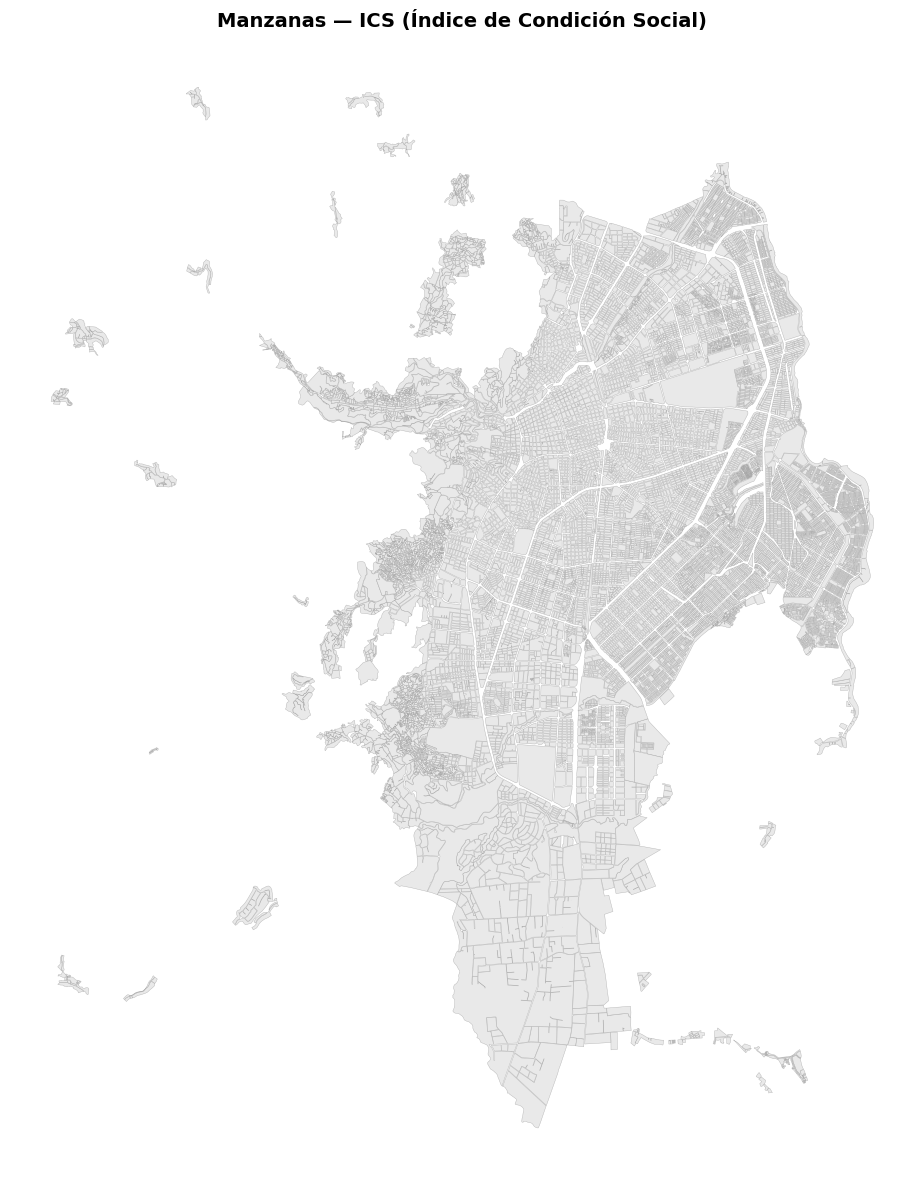

In [21]:
# @title 10. Mapa base — Manzanas ICS
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
gdf_ics.plot(ax=ax, color='#e0e0e0', edgecolor='#999999', linewidth=0.3, alpha=0.7)
ax.set_title('Manzanas — ICS (Índice de Condición Social)', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()


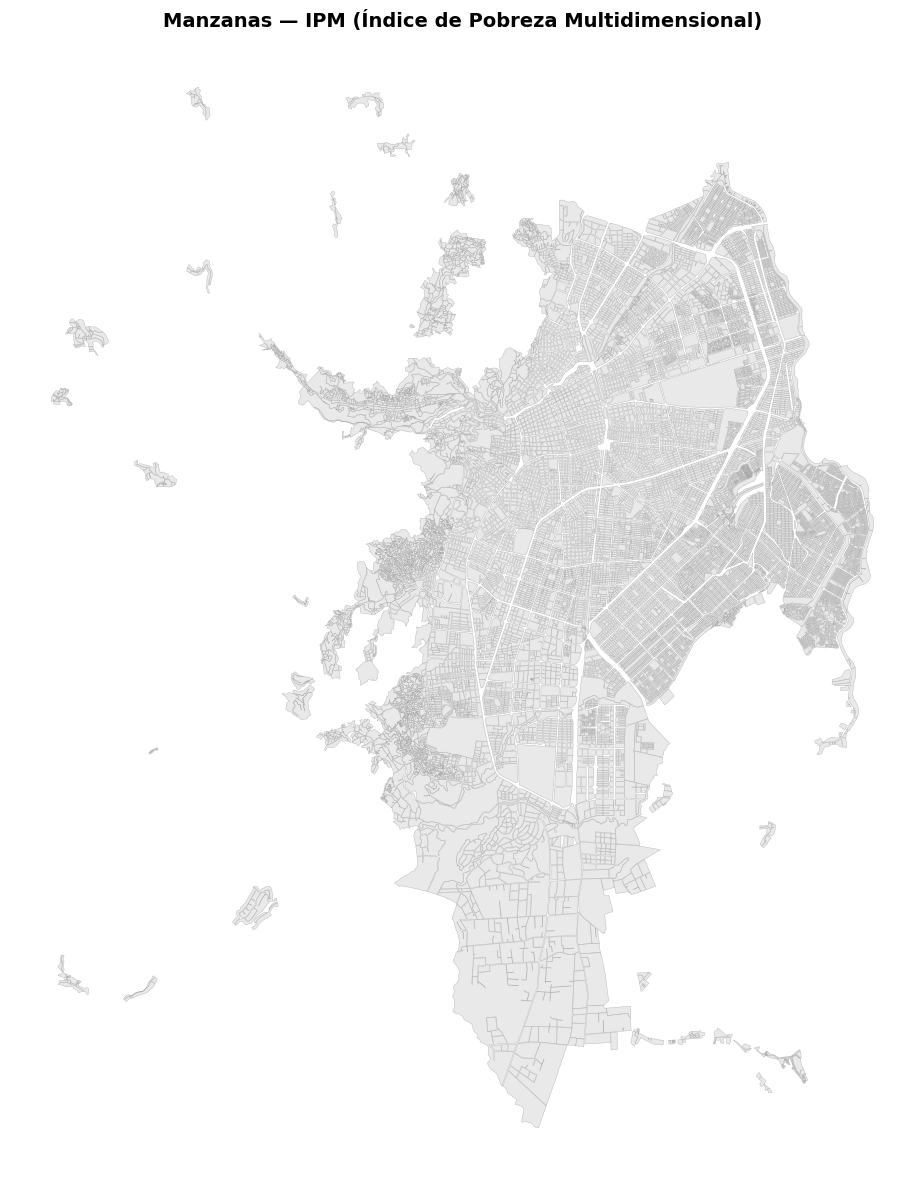

In [22]:
# @title 11. Mapa base — Manzanas IPM
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
gdf_ipm.plot(ax=ax, color='#e0e0e0', edgecolor='#999999', linewidth=0.3, alpha=0.7)
ax.set_title('Manzanas — IPM (Índice de Pobreza Multidimensional)', fontsize=14, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [23]:
# @title 12. Identificar columna de ICS para clasificación
# Buscar columna numérica que contenga el valor del ICS
ics_cols = [c for c in gdf_ics.columns if gdf_ics[c].dtype in ['float64', 'int64']]
print('Columnas numéricas en ICS:', ics_cols)

# Mostrar distribución de las primeras columnas numéricas
for col in ics_cols[:5]:
    print(f'\n{col}:')
    print(gdf_ics[col].describe())


Columnas numéricas en ICS: ['CLASE', 'ics']

CLASE:
count    15658.000000
mean         0.958807
std          0.336837
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          2.000000
Name: CLASE, dtype: float64

ics:
count    15658.000000
mean        29.804883
std         17.176787
min          0.000000
25%         21.582804
50%         29.552778
75%         39.000000
max        335.050018
Name: ics, dtype: float64


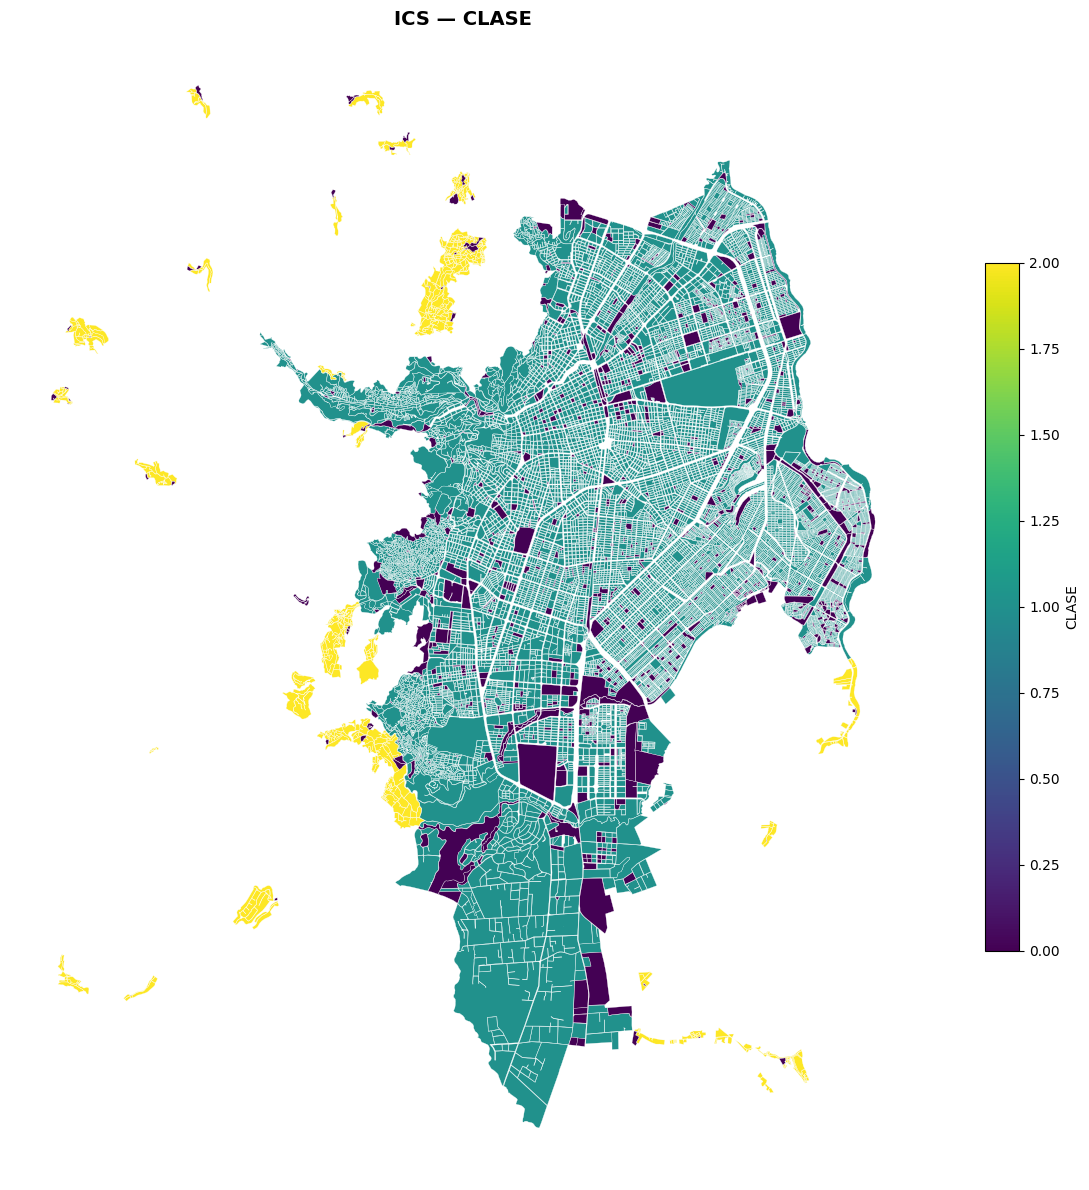

In [24]:
# @title 13. Mapa temático — ICS (si existe columna de valor)
# Identificar columna candidata para mapeo
num_cols_ics = [c for c in gdf_ics.columns if gdf_ics[c].dtype in ['float64', 'int64'] and c.lower() not in ['objectid', 'fid', 'id', 'shape_leng', 'shape_area', 'shape_len', 'shape_le']]

if num_cols_ics:
    col = num_cols_ics[0]
    fig, ax = plt.subplots(1, 1, figsize=(14, 12))
    gdf_ics.plot(column=col, ax=ax, legend=True,
                 cmap='viridis', edgecolor='white', linewidth=0.2,
                 legend_kwds={'label': col, 'shrink': 0.6})
    ax.set_title(f'ICS — {col}', fontsize=14, fontweight='bold')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
else:
    print('No se encontró columna numérica para mapear en ICS')


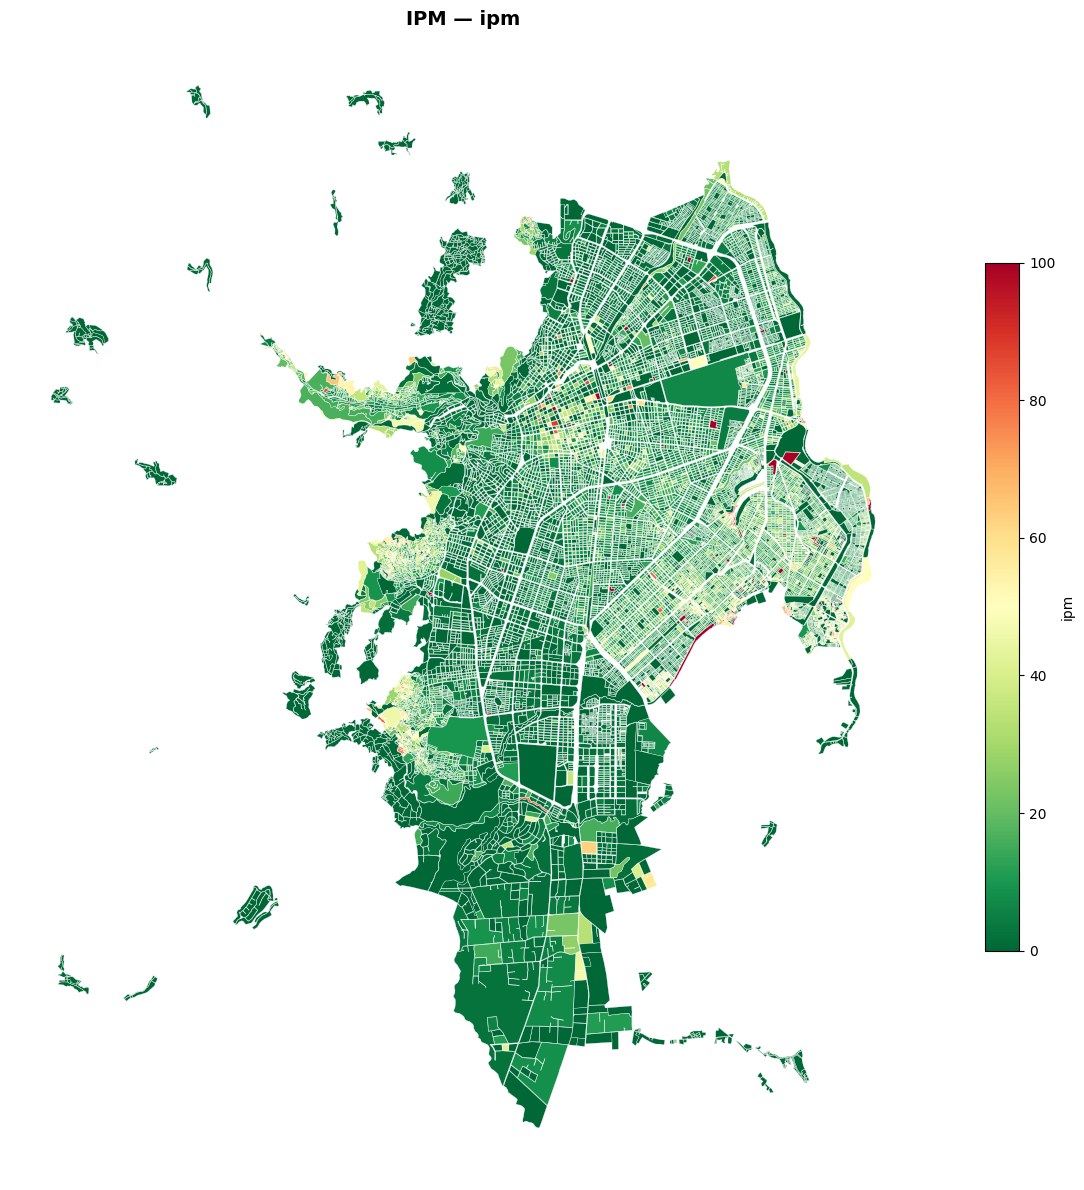

In [25]:
# @title 14. Mapa temático — IPM
num_cols_ipm = [c for c in gdf_ipm.columns if gdf_ipm[c].dtype in ['float64', 'int64'] and c.lower() not in ['objectid', 'fid', 'id', 'shape_leng', 'shape_area', 'shape_len', 'shape_le']]

if num_cols_ipm:
    col = num_cols_ipm[0]
    fig, ax = plt.subplots(1, 1, figsize=(14, 12))
    gdf_ipm.plot(column=col, ax=ax, legend=True,
                 cmap='RdYlGn_r', edgecolor='white', linewidth=0.2,
                 legend_kwds={'label': col, 'shrink': 0.6})
    ax.set_title(f'IPM — {col}', fontsize=14, fontweight='bold')
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()
else:
    print('No se encontró columna numérica para mapear en IPM')


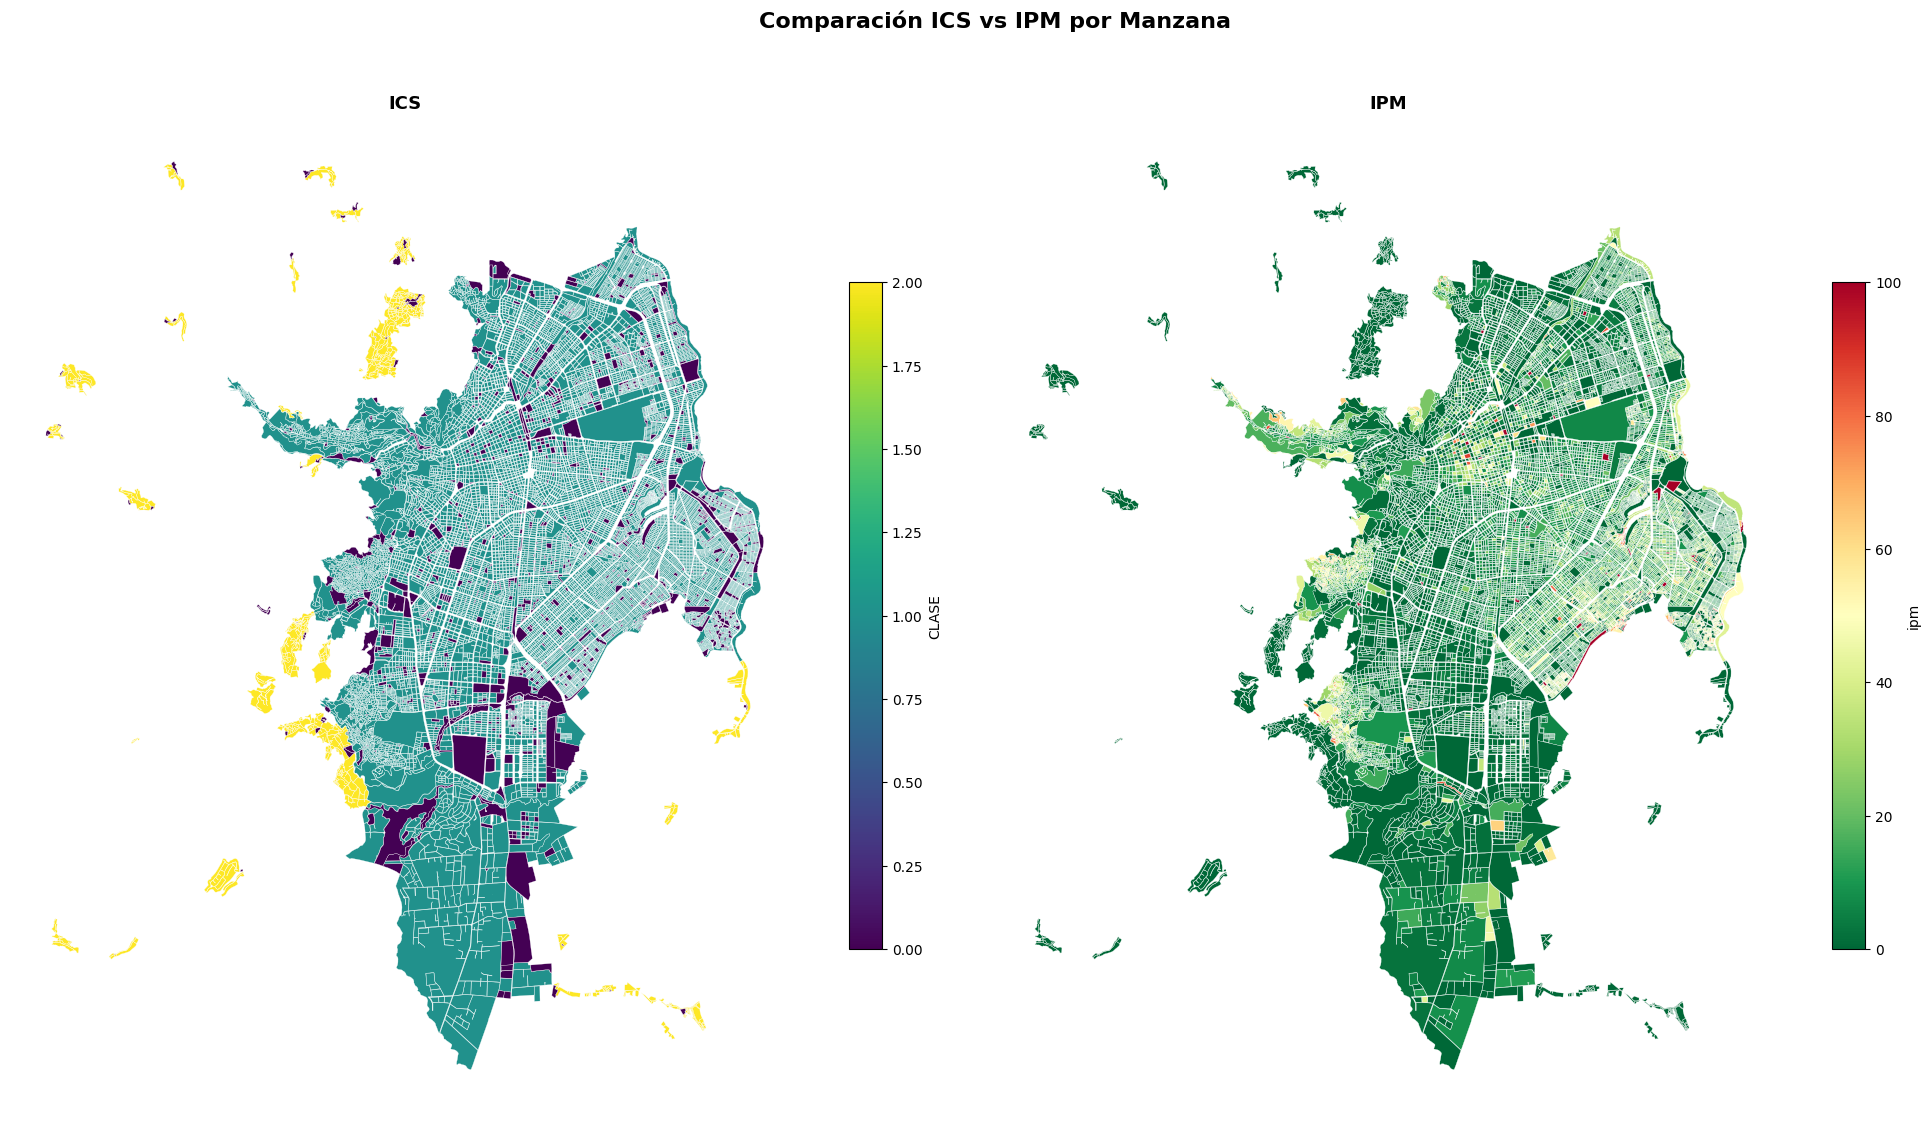

In [26]:
# @title 15. Mapas lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 14))

# ICS
if num_cols_ics:
    gdf_ics.plot(column=num_cols_ics[0], ax=ax1, legend=True,
                 cmap='viridis', edgecolor='white', linewidth=0.2,
                 legend_kwds={'label': num_cols_ics[0], 'shrink': 0.5})
    ax1.set_title('ICS', fontsize=13, fontweight='bold')
else:
    gdf_ics.plot(ax=ax1, color='#e0e0e0', edgecolor='#999999', linewidth=0.2)
    ax1.set_title('ICS (sin datos)', fontsize=13, fontweight='bold')
ax1.set_axis_off()

# IPM
if num_cols_ipm:
    gdf_ipm.plot(column=num_cols_ipm[0], ax=ax2, legend=True,
                 cmap='RdYlGn_r', edgecolor='white', linewidth=0.2,
                 legend_kwds={'label': num_cols_ipm[0], 'shrink': 0.5})
    ax2.set_title('IPM', fontsize=13, fontweight='bold')
else:
    gdf_ipm.plot(ax=ax2, color='#e0e0e0', edgecolor='#999999', linewidth=0.2)
    ax2.set_title('IPM (sin datos)', fontsize=13, fontweight='bold')
ax2.set_axis_off()

plt.suptitle('Comparación ICS vs IPM por Manzana', fontsize=16, fontweight='bold', y=0.92)
plt.tight_layout()
plt.show()


In [27]:
# @title 16. Estadísticas descriptivas
print('=== ICS ===')
if num_cols_ics:
    display(gdf_ics[num_cols_ics].describe())

print('\n=== IPM (shapefile) ===')
if num_cols_ipm:
    display(gdf_ipm[num_cols_ipm].describe())

# Diccionario de variables IPM
diccionario = {
    'analf_': 'Analfabetismo',
    'bajo_': 'Bajo logro educativo',
    'infancia_': 'Barreras primera infancia',
    'inasis_': 'Inasistencia escolar',
    'rezago_': 'Rezago escolar',
    'trab_infan_': 'Trabajo infantil',
    'depen_': 'Dependencia económica',
    'infor_': 'Informalidad',
    'salud_': 'Barreras de salud',
    'asegu_': 'Sin aseguramiento en salud',
    'haci_': 'Hacinamiento crítico',
    'pared_': 'Paredes precarias',
    'excre_': 'Eliminación inadecuada de excretas',
    'pisos_': 'Pisos precarios',
    'agua_': 'Sin acceso a agua mejorada'
}

# Cargar variables IPM desde Excel
xls = pd.ExcelFile(EXCEL_PATH)
sheets = [s for s in xls.sheet_names if s != 'Diccionario']
df_ipm_vars = None
for s in sheets:
    df_var = pd.read_excel(xls, s)
    col_name = df_var.columns[1]
    df_var = df_var.rename(columns={col_name: col_name + '_val'})
    df_var.columns = ['cod_mzn', col_name + '_val']
    if df_ipm_vars is None:
        df_ipm_vars = df_var
    else:
        df_ipm_vars = df_ipm_vars.merge(df_var, on='cod_mzn', how='outer')

val_cols = [c for c in df_ipm_vars.columns if c != 'cod_mzn']
print(f'Cargadas {len(val_cols)} variables IPM para {df_ipm_vars.shape[0]} manzanas')

print('\n=== Variables IPM (Excel) - Estadísticas ===')
display(df_ipm_vars[val_cols].describe().round(2))

# Top 5
means = df_ipm_vars[val_cols].mean().sort_values(ascending=False)
print('\n--- Top 5 variables IPM más críticas ---')
for var in means.head().index:
    label = diccionario.get(var.replace('_val',''), var)
    print(f'  {label}: {means[var]:.2f}%')
print(f'\nVariable más crítica: {diccionario.get(means.index[0].replace("_val",""), means.index[0])} ({means.iloc[0]:.2f}%)')


=== ICS ===


,CLASE,ics
count,15658.000000,15658.000000
mean,0.958807,29.804883
std,0.336837,17.176787
min,0.000000,0.000000
25%,1.000000,21.582804
50%,1.000000,29.552778
75%,1.000000,39.000000
max,2.000000,335.050018



=== IPM (shapefile) ===


,ipm,ANALF_,BAJO_,INFANCIA_,INASIS_,REZAGO_,TRAB_INFAN,DEPEN_,INFOR_,SALUD_,ASEGU_,HACI_,PARED_,EXCRE_,PISOS_,AGUA_
count,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000,15658.000000
mean,11.691155,5.323659,31.614810,2.536535,3.892774,15.050798,0.795583,20.617596,71.284840,4.144026,18.730301,6.850543,0.840873,1.895432,0.430567,1.189167
std,14.733710,7.354803,23.431274,4.504190,6.590420,13.549174,2.683144,14.703059,29.337391,6.877965,12.264133,9.746928,4.837802,9.700233,2.796260,7.216322
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,11.363600,0.000000,0.000000,3.636400,0.000000,11.111100,70.895500,0.000000,11.023600,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.200000,2.792600,30.188700,0.000000,0.000000,12.903200,0.000000,19.613200,81.481500,0.597900,19.178100,3.092800,0.000000,0.000000,0.000000,0.000000
75%,17.100000,8.017650,48.780500,3.894850,5.633800,22.857100,0.000000,28.695700,88.235300,5.952400,26.427675,10.253775,0.000000,0.000000,0.000000,0.000000
max,100.000000,100.000000,100.000000,66.666700,80.000000,100.000000,80.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,80.000000,100.000000


Cargadas 15 variables IPM para 13687 manzanas

=== Variables IPM (Excel) - Estadísticas ===


,analf__val,bajo__val,infancia__val,inasis__val,rezago__val,trab_infan__val,depen__val,infor__val,salud__val,asegu__val,haci__val,pared__val,excre__val,pisos__val,agua__val
count,9512.00,13484.00,6487.00,7435.00,12210.00,2662.00,13415.00,13686.00,7932.00,13187.00,9228.00,1425.00,2008.00,1065.00,1511.00
mean,8.87,37.02,6.15,8.24,19.41,4.70,24.20,81.99,8.22,22.32,11.67,9.40,14.94,6.52,13.50
std,7.70,21.15,5.20,7.49,12.35,4.91,12.93,10.64,7.76,9.94,10.27,13.37,23.29,8.79,20.45
min,0.17,0.55,0.27,0.32,1.04,0.09,0.59,9.52,0.14,1.01,0.16,0.10,0.05,0.11,0.14
25%,3.70,19.88,2.86,3.42,10.05,1.99,15.28,76.19,3.12,15.56,4.52,1.74,1.68,1.56,1.71
50%,6.67,35.48,4.76,5.98,16.95,3.37,22.22,83.33,5.88,21.43,8.70,4.55,4.26,3.37,4.55
75%,11.65,51.95,7.69,10.34,26.03,5.67,30.59,89.19,10.78,27.84,15.50,11.11,16.07,7.79,14.91
max,100.00,100.00,66.67,80.00,100.00,80.00,100.00,100.00,100.00,100.00,100.00,100.00,100.00,80.00,100.00



--- Top 5 variables IPM más críticas ---
  Informalidad: 81.99%
  Bajo logro educativo: 37.02%
  Dependencia económica: 24.20%
  Sin aseguramiento en salud: 22.32%
  Rezago escolar: 19.41%

Variable más crítica: Informalidad (81.99%)


## Enriquecimiento geoespacial: Comunas y zonas de interés


In [28]:
# @title 17. Cargar GeoJSONs auxiliares (comunas, ITT territories)
gdf_comunas = gpd.read_file(PATH_COMUNAS)
print(f'Comunas: {gdf_comunas.shape[0]} geometrías')

# Cargar polígonos ITT dinámicamente
import glob
itt_files = glob.glob(os.path.join(PATH_ITT_DIR, 'poligono_*.geojson'))
gdf_itt = {}
for f in itt_files:
    name = os.path.basename(f).replace('poligono_', '').replace('.geojson', '').replace('_Buffer_100', '')
    gdf_itt[name] = gpd.read_file(f)
    print(f'Cargado {name}: {gdf_itt[name].shape[0]} geometrías')

# Asignar específicamente para compatibilidad con celdas posteriores
gdf_obrero = gdf_itt.get('Barrio_Obrero')
gdf_roosevelt = gdf_itt.get('Roosevelt')
gdf_oriente = gdf_itt.get('Oriente')


NameError: name 'PATH_COMUNAS' is not defined

In [ ]:
# @title 18. Unificar CRS y asignar comuna por spatial join
crs_ref = gdf_ics.crs
print(f'CRS de referencia (ICS): {crs_ref}')

gdf_comunas_proj = gdf_comunas.to_crs(crs_ref)
gdf_ipm_proj = gdf_ipm.to_crs(crs_ref)

gdf_ics_con_comuna = gpd.sjoin(gdf_ics, gdf_comunas_proj[['comuna', 'nombre', 'geometry']], how='left', predicate='intersects')
gdf_ipm_con_comuna = gpd.sjoin(gdf_ipm_proj, gdf_comunas_proj[['comuna', 'nombre', 'geometry']], how='left', predicate='intersects')

comunas_ics = gdf_ics_con_comuna['comuna'].notna().sum()
comunas_ipm = gdf_ipm_con_comuna['comuna'].notna().sum()
print(f'Manzanas ICS con comuna asignada: {comunas_ics} / {len(gdf_ics_con_comuna)}')
print(f'Manzanas IPM con comuna asignada: {comunas_ipm} / {len(gdf_ipm_con_comuna)}')


CRS de referencia (ICS): PROJCS["MAGNA-SIRGAS / Cali urban grid",GEOGCS["MAGNA-SIRGAS",DATUM["Marco_Geocentrico_Nacional_de_Referencia",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6686"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",3.44188333333333],PARAMETER["central_meridian",-76.5205625],PARAMETER["scale_factor",1],PARAMETER["false_easting",1061900.18],PARAMETER["false_northing",872364.63],UNIT["m",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
Manzanas ICS con comuna asignada: 14629 / 15730
Manzanas IPM con comuna asignada: 14629 / 15730


In [ ]:
# @title 19. Vista previa con comuna asignada
print('=== ICS con comuna ===')
display(gdf_ics_con_comuna.drop(columns='index_right', errors='ignore').head())

print('\n=== IPM con comuna ===')
display(gdf_ipm_con_comuna.drop(columns='index_right', errors='ignore').head())


=== ICS con comuna ===


,COD_MZN,CLASE,ZONA,cod_dane_a,ics,geometry,comuna,nombre
0,7600110000000001010101,1.0,Urbana,7600110000000001010101,32.883636,"POLYGON ((1056006.78 873670.289, 1056076.267 8...",1.0,Comuna 1
1,7600110000000001010102,1.0,Urbana,7600110000000001010102,26.022223,"POLYGON ((1056175.765 873704.041, 1056175.434 ...",1.0,Comuna 1
2,7600110000000001010111,1.0,Urbana,7600110000000001010111,30.111376,"POLYGON ((1055884.986 873862.235, 1055885.068 ...",1.0,Comuna 1
3,7600110000000001010112,1.0,Urbana,7600110000000001010112,29.542585,"POLYGON ((1055769.35 873772.781, 1055751.434 8...",1.0,Comuna 1
4,7600110000000001010113,1.0,Urbana,7600110000000001010113,33.991302,"POLYGON ((1055744.978 873889.931, 1055748.753 ...",1.0,Comuna 1



=== IPM con comuna ===


,COD_DPTO,COD_MPIO,COD_DANE,ipm,geometry,comuna,nombre
0,76,76001,7600110000000001010101,5.7,"POLYGON ((1056006.779 873670.289, 1056076.267 ...",1.0,Comuna 1
1,76,76001,7600110000000001010102,8.9,"POLYGON ((1056175.765 873704.041, 1056175.434 ...",1.0,Comuna 1
2,76,76001,7600110000000001010111,6.3,"POLYGON ((1055884.986 873862.235, 1055885.068 ...",1.0,Comuna 1
3,76,76001,7600110000000001010112,10.5,"POLYGON ((1055769.35 873772.781, 1055751.434 8...",1.0,Comuna 1
4,76,76001,7600110000000001010113,13.0,"POLYGON ((1055744.978 873889.931, 1055748.753 ...",1.0,Comuna 1


In [ ]:
# @title 20. Estadísticas de ICS, IPM y variables por comuna
print('=== ICS promedio por comuna ===')
ics_por_comuna = gdf_ics_con_comuna.groupby('nombre').agg(
    manzanas=('cod_dane_a', 'count'),
    ics_promedio=('ics', 'mean'),
    ics_min=('ics', 'min'),
    ics_max=('ics', 'max')
).round(2).sort_values('ics_promedio', ascending=False)
display(ics_por_comuna)

print('=== IPM global promedio por comuna ===')
ipm_por_comuna = gdf_ipm_con_comuna.groupby('nombre').agg(
    manzanas=('COD_DANE', 'count'),
    ipm_promedio=('ipm', 'mean'),
    ipm_min=('ipm', 'min'),
    ipm_max=('ipm', 'max')
).round(2).sort_values('ipm_promedio')
display(ipm_por_comuna)

# Merge Excel vars con ICS para obtener geometrías
# Clave: quitar los 2 dígitos de comuna del código Excel
df_ipm_vars['COD_MZN'] = df_ipm_vars['cod_mzn'].astype(str).str[:6] + df_ipm_vars['cod_mzn'].astype(str).str[8:]

df_vars_geom = gdf_ics[['COD_MZN', 'geometry']].merge(
    df_ipm_vars, on='COD_MZN', how='inner')
gdf_vars = gpd.GeoDataFrame(df_vars_geom, crs=gdf_ics.crs)
print(f'\nMerge Excel+ICS: {len(gdf_vars)}/{len(df_ipm_vars)} manzanas con geometría')

# Spatial join con comunas
gdf_vars_comuna = gpd.sjoin(gdf_vars, gdf_comunas_proj[['comuna', 'nombre', 'geometry']],
                             how='left', predicate='intersects')

# Top 3 variables IPM por comuna
print('\n=== Top 3 variables IPM por comuna ===')
comuna_stats = gdf_vars_comuna.groupby('nombre')[val_cols].mean().round(2)
top3_vars = means.head(3).index.tolist()
for var in top3_vars:
    label = diccionario.get(var.replace('_val',''), var)
    df_show = comuna_stats[var].sort_values(ascending=False).head(5).to_frame(label)
    print(f'\n{label} (top 5 comunas):')
    display(df_show)


=== ICS promedio por comuna ===


,manzanas,ics_promedio,ics_min,ics_max
nombre,,,,
Comuna 22,148,59.81,0.0,153.31
Comuna 19,685,44.42,0.0,97.10
Comuna 2,812,43.72,0.0,99.06
Comuna 17,760,43.58,0.0,98.00
Comuna 5,561,35.60,0.0,62.94
Comuna 10,551,34.84,0.0,75.46
Comuna 8,580,32.44,0.0,108.13
Comuna 12,323,31.43,0.0,87.28
Comuna 16,515,30.79,0.0,83.93


=== IPM global promedio por comuna ===


,manzanas,ipm_promedio,ipm_min,ipm_max
nombre,,,,
Comuna 17,892,3.35,0.0,100.0
Comuna 19,798,3.55,0.0,100.0
Comuna 22,171,4.35,0.0,83.3
Comuna 2,937,4.50,0.0,100.0
Comuna 5,635,4.80,0.0,83.3
Comuna 10,620,6.17,0.0,70.7
Comuna 8,642,8.53,0.0,100.0
Comuna 6,894,8.90,0.0,100.0
Comuna 4,545,9.21,0.0,100.0



Merge Excel+ICS: 13614/13687 manzanas con geometría

=== Top 3 variables IPM por comuna ===

Informalidad (top 5 comunas):


,Informalidad
nombre,
Comuna 20,87.66
Comuna 9,87.04
Comuna 15,86.98
Comuna 13,86.68
Comuna 14,86.51



Bajo logro educativo (top 5 comunas):


,Bajo logro educativo
nombre,
Comuna 20,61.76
Comuna 14,51.87
Comuna 1,49.17
Comuna 13,48.61
Comuna 15,46.33



Dependencia económica (top 5 comunas):


,Dependencia económica
nombre,
Comuna 15,31.36
Comuna 14,30.82
Comuna 21,30.56
Comuna 13,28.87
Comuna 20,28.22


In [ ]:
# @title 21. Identificar manzanas en zonas especiales
# Manejar CRS de Barrio Obrero (ESRI:103599)
if gdf_obrero.crs is None:
    gdf_obrero = gdf_obrero.set_crs('ESRI:103599')
gdf_obrero_proj = gdf_obrero.to_crs(crs_ref)

gdf_roosevelt_proj = gdf_roosevelt.to_crs(crs_ref)

# Identificar manzanas dentro de cada zona
gdf_ics['en_barrio_obrero'] = ~gpd.sjoin(gdf_ics, gdf_obrero_proj, how='left', predicate='intersects')['index_right'].isna()
gdf_ics['en_roosevelt'] = ~gpd.sjoin(gdf_ics, gdf_roosevelt_proj, how='left', predicate='intersects')['index_right'].isna()

en_obrero = gdf_ics['en_barrio_obrero'].sum()
en_roosevelt = gdf_ics['en_roosevelt'].sum()
print(f'Manzanas en Barrio Obrero: {en_obrero}')
print(f'Manzanas en Roosevelt: {en_roosevelt}')

if en_obrero > 0:
    print('=== ICS en Barrio Obrero ===')
    display(gdf_ics[gdf_ics['en_barrio_obrero']][['COD_MZN', 'ics']])

if en_roosevelt > 0:
    print('=== ICS en Roosevelt ===')
    display(gdf_ics[gdf_ics['en_roosevelt']][['COD_MZN', 'ics']])


Manzanas en Barrio Obrero: 16
Manzanas en Roosevelt: 41
=== ICS en Barrio Obrero ===


,COD_MZN,ics
5217,7600110000000009100106,30.275511
5218,7600110000000009100107,31.276316
5224,7600110000000009100114,27.984537
5225,7600110000000009100115,23.335649
5234,7600110000000009100209,23.000000
5235,7600110000000009100210,26.299999
5236,7600110000000009100211,23.383051
5241,7600110000000009100303,24.817074
5242,7600110000000009100304,25.757576
5243,7600110000000009100305,19.813725


=== ICS en Roosevelt ===


,COD_MZN,ics
12609,7600110000000019320110,45.943821
12610,7600110000000019320111,37.746033
12611,7600110000000019320113,60.860466
12612,7600110000000019320114,50.577465
12635,7600110000000019330114,56.393940
12636,7600110000000019330115,47.581394
12637,7600110000000019330116,46.750000
12655,7600110000000019330214,56.911110
12656,7600110000000019330216,50.396553
12657,7600110000000019330217,74.533333


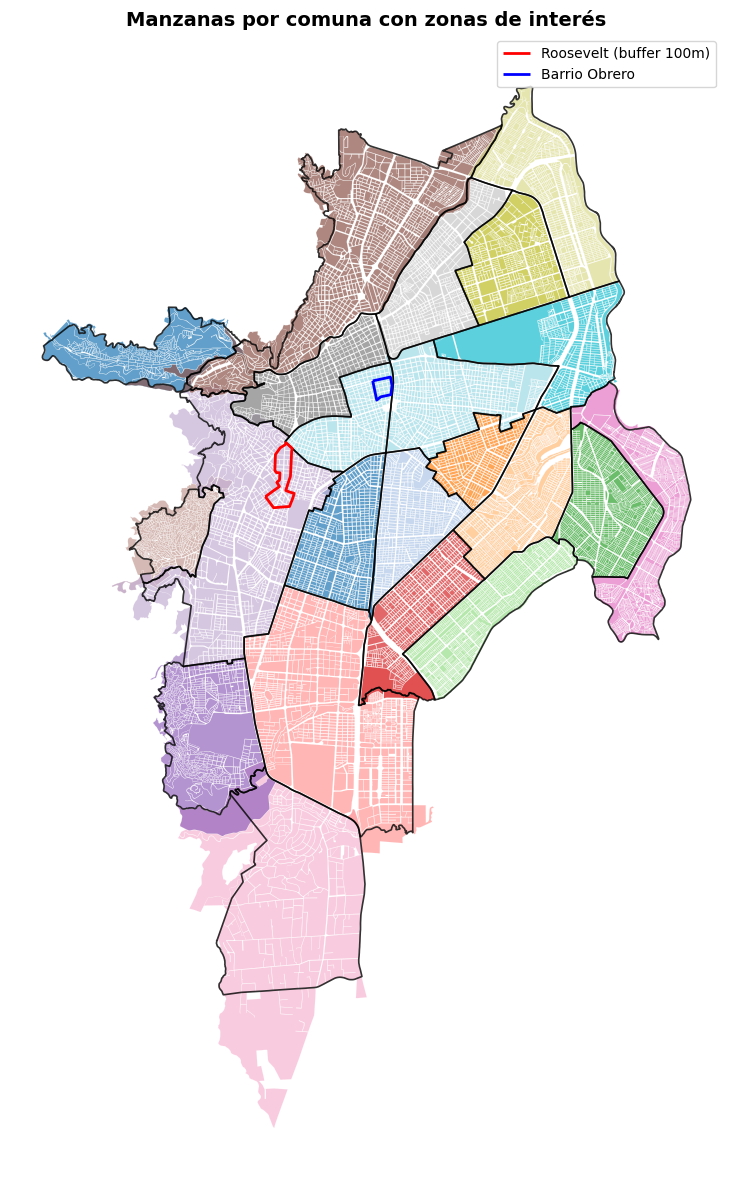

In [ ]:
# @title 22. Mapa - Manzanas por comuna con zonas de inter\u00e9s
fig, ax = plt.subplots(1, 1, figsize=(14, 12))

gdf_ics_con_comuna.plot(column='nombre', ax=ax, legend=True,
                         cmap='tab20', edgecolor='white', linewidth=0.1, alpha=0.7,
                         legend_kwds={'title': 'Comuna', 'loc': 'upper left', 'fontsize': 8})

gdf_comunas_proj.boundary.plot(ax=ax, color='black', linewidth=1.2, alpha=0.8)
gdf_roosevelt_proj.boundary.plot(ax=ax, color='red', linewidth=2, label='Roosevelt (buffer 100m)')
gdf_obrero_proj.boundary.plot(ax=ax, color='blue', linewidth=2, label='Barrio Obrero')

ax.set_title('Manzanas por comuna con zonas de inter\u00e9s', fontsize=14, fontweight='bold')
ax.set_axis_off()
ax.legend()
plt.tight_layout()
plt.show()


NameError: name 'gdf_vars' is not defined

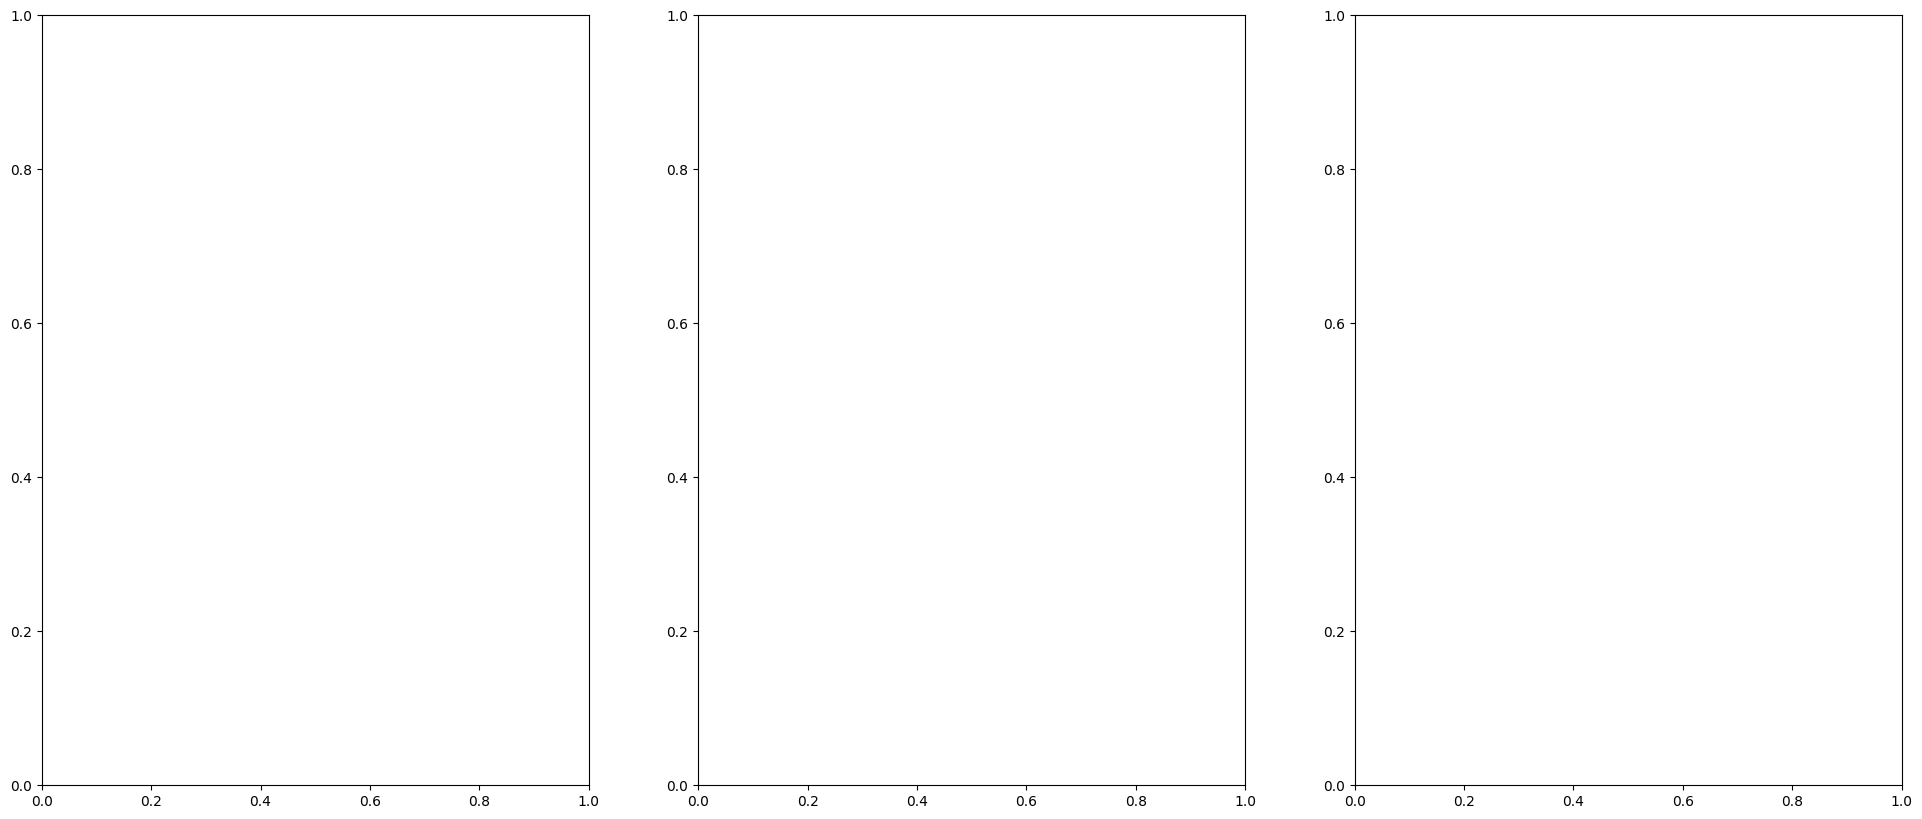

In [29]:
# @title 23. Mapa - Variables IPM mÃ¡s CrÃ­ticas con Filtro de Tramos
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -------------------------------------------------------------------------
# AQUÃ PUEDES ACTIVAR O DESACTIVAR LOS POLÃGONOS A MOSTRAR.
# Edita la lista a continuaciÃ³n, quitando o poniendo los nombres de los tramos.
# Nombres disponibles: 'Barrio_Obrero', 'Roosevelt', 'Oriente', 
# 'ciudad_de_cali_T1', 'ciudad_de_cali_T2', ..., 'ciudad_de_cali_T8'
# -------------------------------------------------------------------------
ZONAS_VISIBLES = [
    'Barrio_Obrero', 
    'Roosevelt', 
    'ciudad_de_cali_T1', 
    'ciudad_de_cali_T2', 
    'ciudad_de_cali_T3', 
    'ciudad_de_cali_T4', 
    'ciudad_de_cali_T5', 
    'ciudad_de_cali_T6', 
    'ciudad_de_cali_T7', 
    'ciudad_de_cali_T8'
]

# Mapa de las 3 variables IPM con mayor incidencia
top3_vars = means.head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(24, 10))

# Paleta de colores optimizada (colorblind friendly)
cmap_tramos = plt.get_cmap('tab20')

for idx_ax, (ax, var) in enumerate(zip(axes, top3_vars)):
    label = diccionario.get(var.replace('_val',''), var)
    
    # Capa base: Variables IPM
    gdf_vars.plot(column=var, ax=ax, legend=True,
                 cmap='cividis', edgecolor='white', linewidth=0.1,
                 legend_kwds={'shrink': 0.4, 'label': 'Incidencia %'},
                 vmin=0, vmax=100)
    
    # Capa 2: Comunas (transparente)
    gdf_comunas_proj.boundary.plot(ax=ax, color='black', linewidth=0.6, alpha=0.3)
    
    # Capa 3: PolÃ­gonos ITT Seleccionados (Relleno sÃ³lido)
    for i, zona_name in enumerate(ZONAS_VISIBLES):
        if zona_name in gdf_itt:
            color_z = cmap_tramos(i % 20)
            gdf_itt[zona_name].to_crs(gdf_vars.crs).plot(
                ax=ax, color=color_z, alpha=0.7, edgecolor='black', linewidth=1)
            
    ax.set_title(label, fontsize=14, fontweight='bold')
    ax.set_axis_off()

# Leyenda dinÃ¡mica de zonas
legend_patches = []
for i, zona_name in enumerate(ZONAS_VISIBLES):
    if zona_name in gdf_itt:
        legend_patches.append(Patch(facecolor=cmap_tramos(i % 20), 
                                    edgecolor='black', alpha=0.7, 
                                    label=zona_name.replace('_', ' ').title()))

fig.legend(handles=legend_patches, loc='lower center', ncol=5, 
           fontsize=11, framealpha=0.9, title="Zonas de IntervenciÃ³n Seleccionadas")

plt.suptitle('Vulnerabilidad IPM y PolÃ­gonos de IntervenciÃ³n ITT', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.1, 1, 0.95])
plt.show()


In [ ]:
# @title 24. Filtrar variables IPM por zona
# Spatial join de variables IPM con cada zona de interés
gdf_vars_obrero = gpd.sjoin(gdf_vars, gdf_obrero_proj, how='inner', predicate='intersects')
gdf_vars_roosevelt = gpd.sjoin(gdf_vars, gdf_roosevelt_proj, how='inner', predicate='intersects')

print(f'Manzanas con vars IPM en Barrio Obrero: {len(gdf_vars_obrero)}')
print(f'Manzanas con vars IPM en Roosevelt: {len(gdf_vars_roosevelt)}')

# Promedio por zona
means_obrero = gdf_vars_obrero[val_cols].mean().sort_values(ascending=False)
means_roosevelt = gdf_vars_roosevelt[val_cols].mean().sort_values(ascending=False)

print('\n--- Top 5 Barrio Obrero ---')
for v in means_obrero.head().index:
    lbl = diccionario.get(v.replace('_val',''), v)
    print(f'  {lbl}: {means_obrero[v]:.2f}%')

print('\n--- Top 5 Roosevelt ---')
for v in means_roosevelt.head().index:
    lbl = diccionario.get(v.replace('_val',''), v)
    print(f'  {lbl}: {means_roosevelt[v]:.2f}%')


Manzanas con vars IPM en Barrio Obrero: 15
Manzanas con vars IPM en Roosevelt: 34

--- Top 5 Barrio Obrero ---
  Informalidad: 90.31%
  Bajo logro educativo: 53.29%
  Dependencia económica: 23.25%
  Rezago escolar: 19.03%
  Sin aseguramiento en salud: 14.84%

--- Top 5 Roosevelt ---
  Informalidad: 74.36%
  Trabajo infantil: 31.25%
  Sin aseguramiento en salud: 22.05%
  Dependencia económica: 19.09%
  Bajo logro educativo: 17.58%


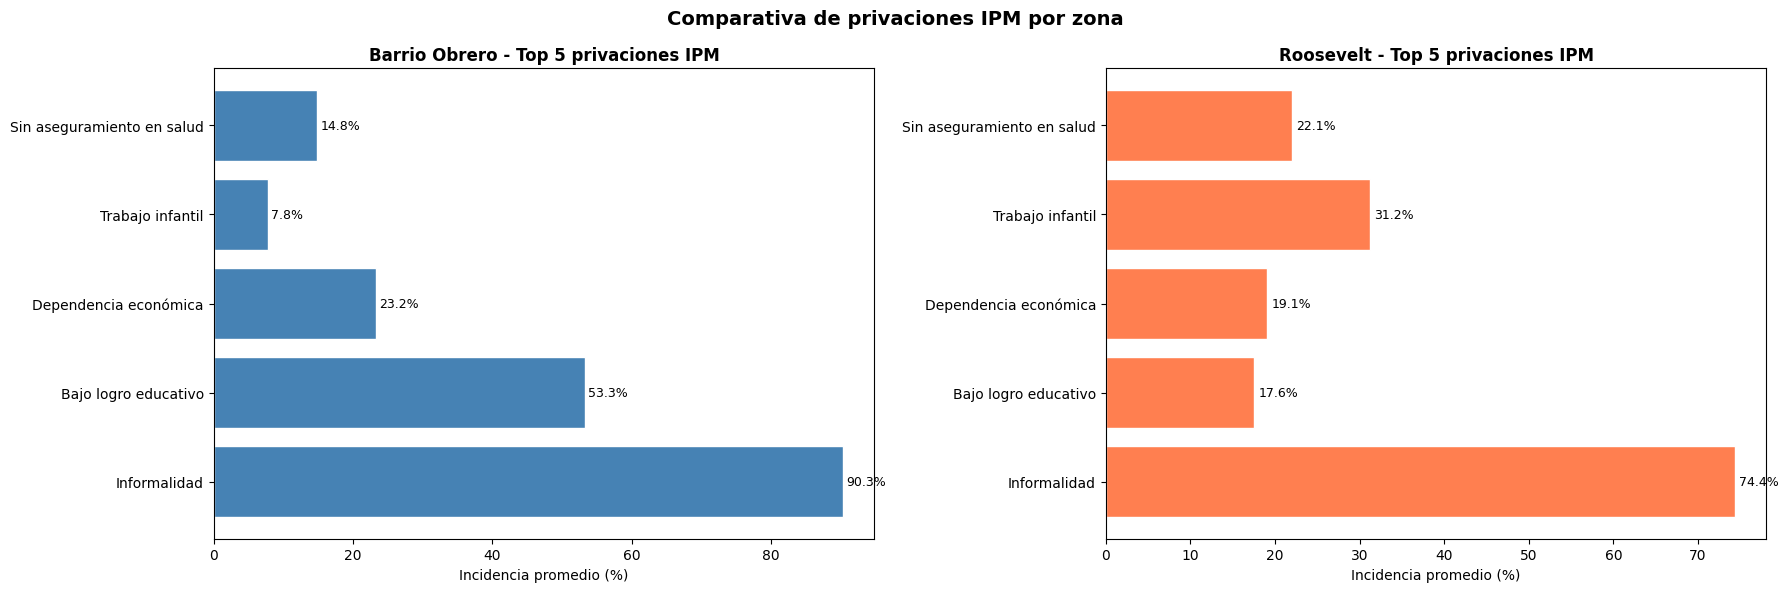

In [ ]:
# @title 25. Gráfico - Comparativa variables IPM por zona
# Top 5 variables combinando ambas zonas
top5_vars = (means_obrero + means_roosevelt).nlargest(5).index.tolist()
top5_labels = [diccionario.get(v.replace('_val',''), v) for v in top5_vars]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Barrio Obrero
vals_obrero = [means_obrero[v] for v in top5_vars]
bars1 = axes[0].barh(top5_labels, vals_obrero, color='steelblue', edgecolor='white')
for bar, v in zip(bars1, vals_obrero):
    axes[0].text(v + 0.5, bar.get_y() + bar.get_height()/2, f'{v:.1f}%',
                 va='center', fontsize=9)
axes[0].set_title('Barrio Obrero - Top 5 privaciones IPM', fontweight='bold')
axes[0].set_xlabel('Incidencia promedio (%)')

# Roosevelt
vals_roosevelt = [means_roosevelt[v] for v in top5_vars]
bars2 = axes[1].barh(top5_labels, vals_roosevelt, color='coral', edgecolor='white')
for bar, v in zip(bars2, vals_roosevelt):
    axes[1].text(v + 0.5, bar.get_y() + bar.get_height()/2, f'{v:.1f}%',
                 va='center', fontsize=9)
axes[1].set_title('Roosevelt - Top 5 privaciones IPM', fontweight='bold')
axes[1].set_xlabel('Incidencia promedio (%)')

plt.suptitle('Comparativa de privaciones IPM por zona', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [ ]:
# @title 26. Mapa - Manzanas por zona con ICS e IPM
# Escala de clasificación del ICS (8 categorías)
ics_escala = [
    (0.4, 20.0, '#FFFF99', 'Bajo'),
    (20.1, 27.0, '#B2FF66', 'Moderado-Bajo'),
    (27.1, 33.1, '#66FF33', 'Moderado'),
    (33.2, 39.8, '#4CD164', 'Moderado-Alto'),
    (39.9, 48.6, '#40A485', 'Alto'),
    (48.7, 60.6, '#2D82A6', 'Muy Alto'),
    (60.7, 80.0, '#2A4B8C', 'Extremo'),
    (80.1, 335.1, '#1A1C78', 'Extremo Maximo')
]

def classificar_ics(val):
    for rmin, rmax, hex_c, cat in ics_escala:
        if rmin <= val <= rmax:
            return cat, hex_c
    return 'Sin dato', '#CCCCCC'

# Merge ICS + IPM para cada zona
def preparar_mapa(gdf_ics_zona, gdf_ipm_zona, nombre):
    if len(gdf_ics_zona) == 0 or len(gdf_ipm_zona) == 0:
        print(f'{nombre}: sin datos')
        return None
    m = gdf_ics_zona.drop(columns=['index_right'], errors='ignore').merge(
        gdf_ipm_zona[['COD_DANE', 'ipm']].drop(columns=['index_right'], errors='ignore'),
        left_on='cod_dane_a', right_on='COD_DANE', how='inner')
    if len(m) == 0:
        print(f'{nombre}: merge sin filas')
        return None
    m['cat_ics'], m['color_ics'] = zip(*m['ics'].apply(classificar_ics))
    print(f'{nombre}: {len(m)} manzanas mapeadas')
    return m

mapa_obrero = preparar_mapa(gdf_obrero_filt, gdf_ipm_obrero, 'Barrio Obrero')
mapa_roosevelt = preparar_mapa(gdf_roosevelt_filt, gdf_ipm_roosevelt, 'Roosevelt')

# Crear figura con leyenda horizontal abajo
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[0.05, 1], width_ratios=[1, 0.05, 1])

# Leyenda ICS (arriba, ocupa todo el ancho)
ax_leg = fig.add_subplot(gs[0, :])
ax_leg.axis('off')
legend_handles = []
for rmin, rmax, hex_c, cat in ics_escala:
    legend_handles.append(plt.Rectangle((0, 0), 1, 1, facecolor=hex_c, edgecolor='gray', linewidth=0.5))
ax_leg.legend(legend_handles,
    [f'{cat}\n({rmin}-{rmax})' for rmin, rmax, _, cat in ics_escala],
    loc='center', ncol=8, frameon=False, fontsize=7)
ax_leg.set_title('Clasificación ICS', fontsize=10, fontweight='bold', pad=5)

# Mapa Barrio Obrero
ax1 = fig.add_subplot(gs[1, 0])
if mapa_obrero is not None:
    gdf_plot = gpd.GeoDataFrame(mapa_obrero, crs=gdf_ics.crs)
    gdf_plot.plot(ax=ax1, color=gdf_plot['color_ics'], edgecolor='white', linewidth=0.5)
    for _, row in gdf_plot.iterrows():
        c = row.geometry.centroid
        ipm_label = f"{row['ipm']:.1f}"
        ax1.text(c.x, c.y, ipm_label, fontsize=6, ha='center', va='center',
                 color='white' if row['ics'] > 39.9 else 'black', fontweight='bold')
ax1.set_title(f"Barrio Obrero ({len(mapa_obrero) if mapa_obrero is not None else 0} mzn)",
             fontweight='bold')
ax1.set_axis_off()

# Separador
ax_sep = fig.add_subplot(gs[1, 1])
ax_sep.axis('off')

# Mapa Roosevelt
ax2 = fig.add_subplot(gs[1, 2])
if mapa_roosevelt is not None:
    gdf_plot2 = gpd.GeoDataFrame(mapa_roosevelt, crs=gdf_ics.crs)
    gdf_plot2.plot(ax=ax2, color=gdf_plot2['color_ics'], edgecolor='white', linewidth=0.5)
    for _, row in gdf_plot2.iterrows():
        c = row.geometry.centroid
        ipm_label = f"{row['ipm']:.1f}"
        ax2.text(c.x, c.y, ipm_label, fontsize=6, ha='center', va='center',
                 color='white' if row['ics'] > 39.9 else 'black', fontweight='bold')
ax2.set_title(f"Roosevelt ({len(mapa_roosevelt) if mapa_roosevelt is not None else 0} mzn)",
              fontweight='bold')
ax2.set_axis_off()

plt.suptitle('Manzanas por zona - Color: clasificación ICS | Etiqueta: IPM global',
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()


NameError: name 'gdf_obrero_filt' is not defined

## Análisis comparativo: Zonas de interés (ICS e IPM)


In [ ]:
# @title 27. Filtrar ICS para cada zona (spatial join)
gdf_obrero_filt = gpd.sjoin(gdf_ics, gdf_obrero_proj, how='inner', predicate='intersects')
gdf_roosevelt_filt = gpd.sjoin(gdf_ics, gdf_roosevelt_proj, how='inner', predicate='intersects')
print(f'Manzanas ICS en Barrio Obrero: {len(gdf_obrero_filt)}')
print(f'Manzanas ICS en Roosevelt: {len(gdf_roosevelt_filt)}')

if len(gdf_obrero_filt) > 0:
    gdf_obrero_filt = gpd.sjoin(gdf_obrero_filt.drop(columns=["index_right"], errors="ignore"),
                                 gdf_comunas_proj[['comuna', 'nombre', 'geometry']],
                                 how='left', predicate='intersects')
if len(gdf_roosevelt_filt) > 0:
    gdf_roosevelt_filt = gpd.sjoin(gdf_roosevelt_filt.drop(columns=["index_right"], errors="ignore"),
                                   gdf_comunas_proj[['comuna', 'nombre', 'geometry']],
                                   how='left', predicate='intersects')



Manzanas ICS en Barrio Obrero: 9
Manzanas ICS en Roosevelt: 41


In [ ]:
# @title 28. Filtrar IPM para cada zona (spatial join)
gdf_ipm_obrero = gpd.sjoin(gdf_ipm_proj, gdf_obrero_proj, how='inner', predicate='intersects')
gdf_ipm_roosevelt = gpd.sjoin(gdf_ipm_proj, gdf_roosevelt_proj, how='inner', predicate='intersects')

print(f'Manzanas IPM en Barrio Obrero: {len(gdf_ipm_obrero)}')
print(f'Manzanas IPM en Roosevelt: {len(gdf_ipm_roosevelt)}')

if len(gdf_ipm_obrero) > 0:
    gdf_ipm_obrero = gpd.sjoin(gdf_ipm_obrero.drop(columns=["index_right"], errors="ignore"),
                               gdf_comunas_proj[['comuna', 'nombre', 'geometry']],
                               how='left', predicate='intersects')
if len(gdf_ipm_roosevelt) > 0:
    gdf_ipm_roosevelt = gpd.sjoin(gdf_ipm_roosevelt.drop(columns=["index_right"], errors="ignore"),
                                  gdf_comunas_proj[['comuna', 'nombre', 'geometry']],
                                  how='left', predicate='intersects')



Manzanas IPM en Barrio Obrero: 9
Manzanas IPM en Roosevelt: 41


In [ ]:
# @title 29. Estadísticas comparativas ICS, IPM global y vars
print('=== COMPARATIVA ICS ===')
comp_ics = pd.DataFrame({
    'Ciudad': gdf_ics['ics'].describe(),
    'Barrio Obrero': gdf_obrero_filt['ics'].describe() if len(gdf_obrero_filt) > 0 else {},
    'Roosevelt': gdf_roosevelt_filt['ics'].describe() if len(gdf_roosevelt_filt) > 0 else {}
}).round(2)
display(comp_ics)

print('\n=== COMPARATIVA IPM global ===')
comp_ipm = pd.DataFrame({
    'Ciudad': gdf_ipm['ipm'].describe(),
    'Barrio Obrero': gdf_ipm_obrero['ipm'].describe() if len(gdf_ipm_obrero) > 0 else {},
    'Roosevelt': gdf_ipm_roosevelt['ipm'].describe() if len(gdf_ipm_roosevelt) > 0 else {}
}).round(2)
display(comp_ipm)

print('\n=== COMPARATIVA variables IPM (promedio) ===')
comp_vars = pd.DataFrame({
    'Barrio Obrero': means_obrero if len(gdf_vars_obrero) > 0 else pd.Series(dtype=float),
    'Roosevelt': means_roosevelt if len(gdf_vars_roosevelt) > 0 else pd.Series(dtype=float)
}).round(2)
if len(comp_vars) > 0:
    comp_vars.index = [diccionario.get(v.replace('_val',''), v) for v in comp_vars.index]
    comp_vars['Diferencia (Roo - BO)'] = (comp_vars['Roosevelt'] - comp_vars['Barrio Obrero']).round(2)
    display(comp_vars.style.background_gradient(cmap='RdYlGn_r', axis=None))
else:
    print('Sin datos de variables IPM por zona')


=== COMPARATIVA ICS ===


,Ciudad,Barrio Obrero,Roosevelt
count,15658.00,9.00,41.00
mean,29.80,24.86,39.71
std,17.18,3.12,20.23
min,0.00,19.81,0.00
25%,21.58,23.34,37.75
50%,29.55,24.82,44.72
75%,39.00,27.98,51.31
max,335.05,28.53,74.53



=== COMPARATIVA IPM global ===


,Ciudad,Barrio Obrero,Roosevelt
count,15658.00,9.00,41.00
mean,11.69,11.58,3.85
std,14.73,9.76,5.32
min,0.00,0.00,0.00
25%,0.00,2.00,0.00
50%,7.20,11.30,2.50
75%,17.10,18.30,7.10
max,100.00,25.60,25.00



=== COMPARATIVA variables IPM (promedio) ===


,Barrio Obrero,Roosevelt,Diferencia (Roo - BO)
Sin acceso a agua mejorada,nan,2.260000,nan
Analfabetismo,11.810000,9.480000,-2.330000
Sin aseguramiento en salud,15.040000,22.050000,7.010000
Bajo logro educativo,51.220000,17.580000,-33.640000
Dependencia económica,21.680000,19.090000,-2.590000
Eliminación inadecuada de excretas,4.640000,2.300000,-2.340000
Hacinamiento crítico,15.400000,6.050000,-9.350000
Inasistencia escolar,13.690000,4.890000,-8.800000
Barreras primera infancia,7.470000,7.080000,-0.390000
Informalidad,90.490000,74.360000,-16.130000


/tmp/ipykernel_1239/3698107963.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0, 1].boxplot(datos_ics, labels=labels_ics, patch_artist=True, showmeans=True)
/tmp/ipykernel_1239/3698107963.py:44: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1, 1].boxplot(datos_ipm, labels=labels_ipm, patch_artist=True, showmeans=True)


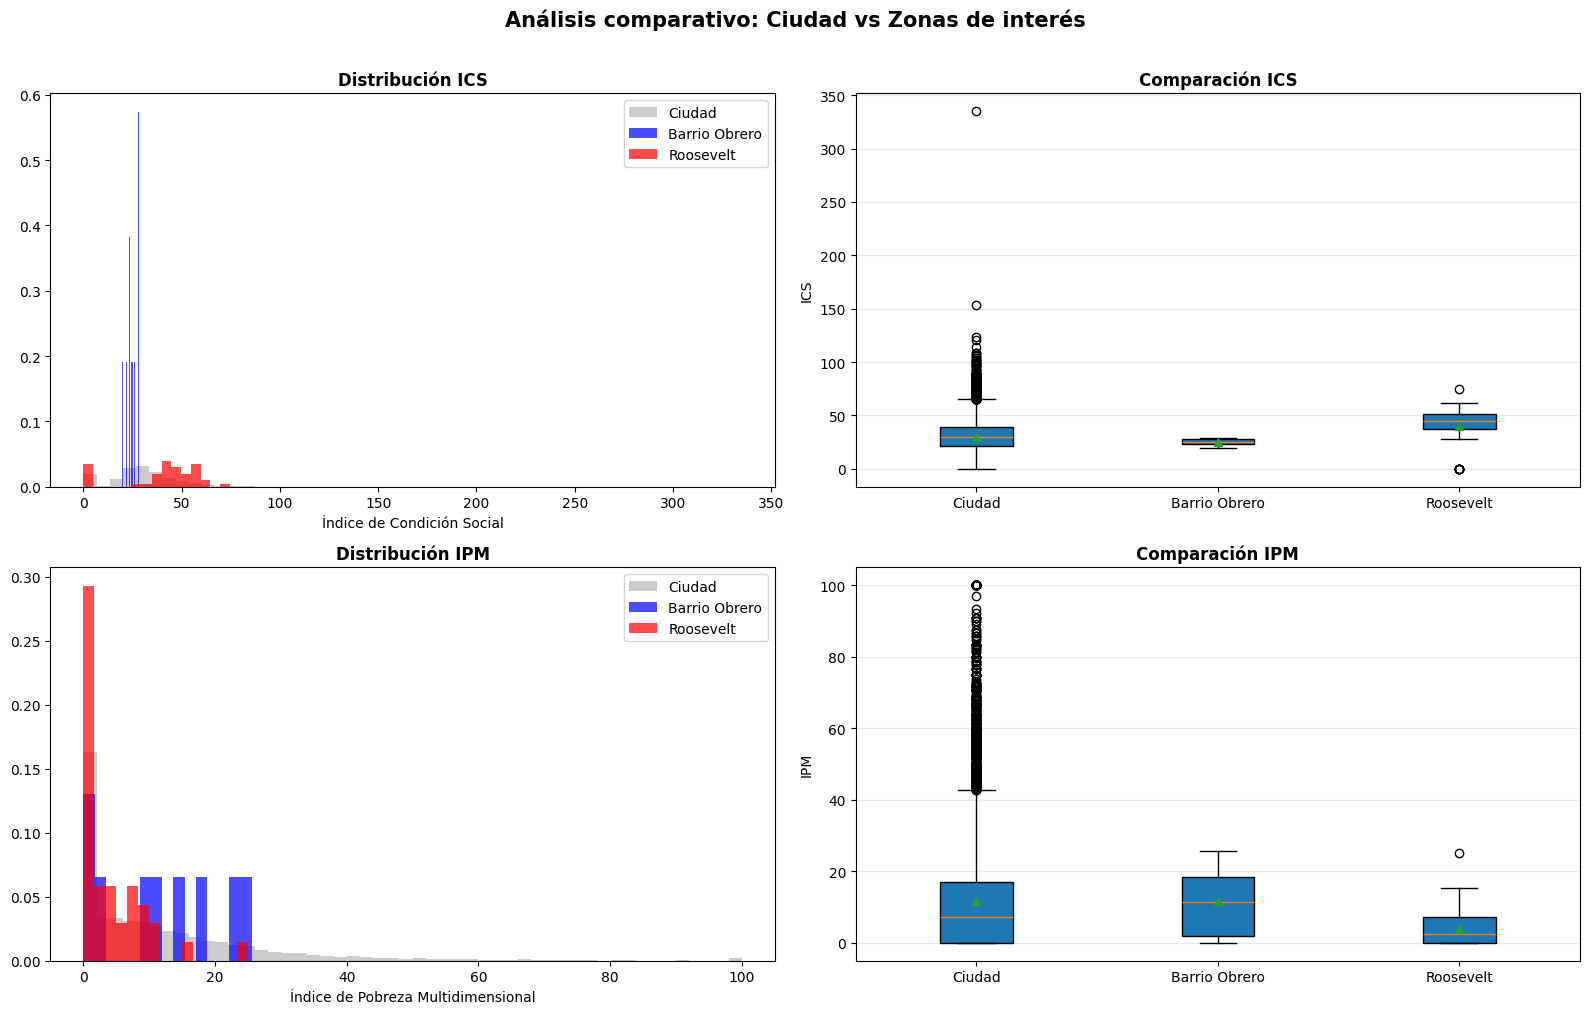

In [ ]:
# @title 30. Gráficos comparativos ICS e IPM por zona
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# --- Histograma ICS ---
axes[0, 0].hist(gdf_ics['ics'].dropna(), bins=50, alpha=0.4, label='Ciudad', color='gray', density=True)
if len(gdf_obrero_filt) > 0:
    axes[0, 0].hist(gdf_obrero_filt['ics'].dropna(), bins=15, alpha=0.7,
                     label='Barrio Obrero', color='blue', density=True)
if len(gdf_roosevelt_filt) > 0:
    axes[0, 0].hist(gdf_roosevelt_filt['ics'].dropna(), bins=15, alpha=0.7,
                     label='Roosevelt', color='red', density=True)
axes[0, 0].set_title('Distribución ICS', fontweight='bold')
axes[0, 0].set_xlabel('Índice de Condición Social')
axes[0, 0].legend()

# --- Boxplot ICS ---
datos_ics = [gdf_ics['ics'].dropna()]; labels_ics = ['Ciudad']
if len(gdf_obrero_filt) > 0:
    datos_ics.append(gdf_obrero_filt['ics'].dropna()); labels_ics.append('Barrio Obrero')
if len(gdf_roosevelt_filt) > 0:
    datos_ics.append(gdf_roosevelt_filt['ics'].dropna()); labels_ics.append('Roosevelt')
bp1 = axes[0, 1].boxplot(datos_ics, labels=labels_ics, patch_artist=True, showmeans=True)
axes[0, 1].set_title('Comparación ICS', fontweight='bold')
axes[0, 1].set_ylabel('ICS'); axes[0, 1].grid(axis='y', alpha=0.3)

# --- Histograma IPM ---
axes[1, 0].hist(gdf_ipm['ipm'].dropna(), bins=50, alpha=0.4, label='Ciudad', color='gray', density=True)
if len(gdf_ipm_obrero) > 0:
    axes[1, 0].hist(gdf_ipm_obrero['ipm'].dropna(), bins=15, alpha=0.7,
                     label='Barrio Obrero', color='blue', density=True)
if len(gdf_ipm_roosevelt) > 0:
    axes[1, 0].hist(gdf_ipm_roosevelt['ipm'].dropna(), bins=15, alpha=0.7,
                     label='Roosevelt', color='red', density=True)
axes[1, 0].set_title('Distribución IPM', fontweight='bold')
axes[1, 0].set_xlabel('Índice de Pobreza Multidimensional')
axes[1, 0].legend()

# --- Boxplot IPM ---
datos_ipm = [gdf_ipm['ipm'].dropna()]; labels_ipm = ['Ciudad']
if len(gdf_ipm_obrero) > 0:
    datos_ipm.append(gdf_ipm_obrero['ipm'].dropna()); labels_ipm.append('Barrio Obrero')
if len(gdf_ipm_roosevelt) > 0:
    datos_ipm.append(gdf_ipm_roosevelt['ipm'].dropna()); labels_ipm.append('Roosevelt')
bp2 = axes[1, 1].boxplot(datos_ipm, labels=labels_ipm, patch_artist=True, showmeans=True)
axes[1, 1].set_title('Comparación IPM', fontweight='bold')
axes[1, 1].set_ylabel('IPM'); axes[1, 1].grid(axis='y', alpha=0.3)

plt.suptitle('Análisis comparativo: Ciudad vs Zonas de interés', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## Relación ICS vs IPM por zona de interés


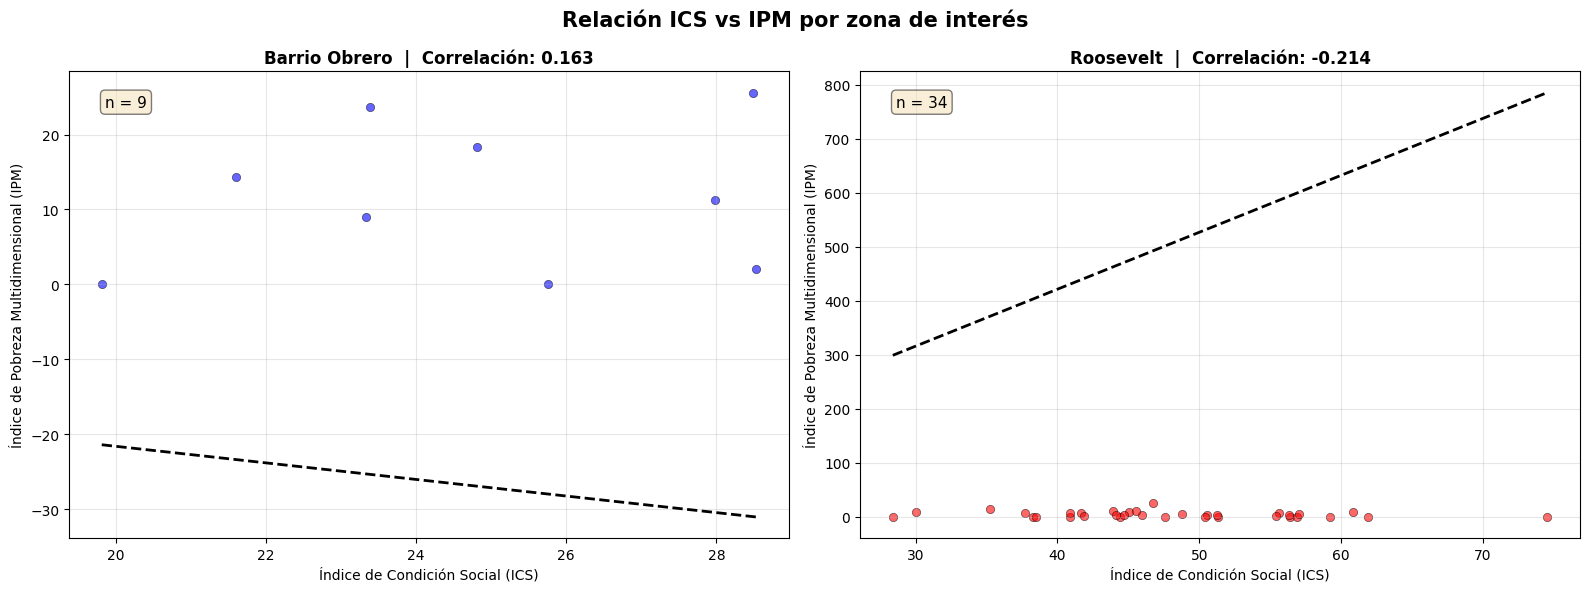

In [ ]:
# @title 31. Relación ICS vs IPM - scatter por zona
if len(gdf_obrero_filt) > 0 and len(gdf_ipm_obrero) > 0:
    merge_obrero = gdf_obrero_filt.merge(
        gdf_ipm_obrero[['COD_DANE', 'ipm']], left_on='cod_dane_a', right_on='COD_DANE', how='inner')
if len(gdf_roosevelt_filt) > 0 and len(gdf_ipm_roosevelt) > 0:
    merge_roosevelt = gdf_roosevelt_filt.merge(
        gdf_ipm_roosevelt[['COD_DANE', 'ipm']], left_on='cod_dane_a', right_on='COD_DANE', how='inner')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, nombre, color in [
    (ax1, merge_obrero if len(gdf_obrero_filt) > 0 else None, 'Barrio Obrero', 'blue'),
    (ax2, merge_roosevelt if len(gdf_roosevelt_filt) > 0 else None, 'Roosevelt', 'red')
]:
    if data is not None and len(data) > 0:
        x, y = data['ics'], data['ipm']
        ax.scatter(x, y, alpha=0.6, color=color, edgecolors='black', linewidth=0.5)
        coeffs = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_line, coeffs[0] + coeffs[1] * x_line, color='black', linewidth=2, linestyle='--')
        corr = x.corr(y)
        ax.set_title(f'{nombre}  |  Correlación: {corr:.3f}', fontweight='bold')
        ax.text(0.05, 0.95, f'n = {len(data)}', transform=ax.transAxes,
                fontsize=11, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    else:
        ax.text(0.5, 0.5, 'Sin datos', ha='center', va='center', fontsize=14)
    ax.set_xlabel('Índice de Condición Social (ICS)')
    ax.set_ylabel('Índice de Pobreza Multidimensional (IPM)')
    ax.grid(alpha=0.3)

plt.suptitle('RelaciÃ³n ICS vs IPM por zona de interÃ©s', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## CÃ¡lculo de Ãreas y AnÃ¡lisis de Tramos (Ciudad de Cali)

ImplementaciÃ³n de la lÃ³gica de proyecciÃ³n a **MAGNA-SIRGAS / Origen Nacional (EPSG:9377)** para el cÃ¡lculo preciso de superficies y consolidaciÃ³n de los 8 tramos del corredor.


In [ ]:
# @title 32. CÃ¡lculo de Ãreas MÃ©tricas (EPSG:9377)
CRS_PROYECTADO = "EPSG:9377"

areas_report = []
for name, gdf in gdf_itt.items():
    gdf_proj = gdf.to_crs(CRS_PROYECTADO)
    area_m2 = gdf_proj.area.sum()
    area_ha = area_m2 / 10000
    areas_report.append({
        'Zona/Tramo': name.replace('_', ' ').title(),
        'Ãrea (m2)': area_m2,
        'Ãrea (Ha)': area_ha
    })

# Consolidado Ciudad de Cali (8 tramos)
cc_tramos = [gdf for name, gdf in gdf_itt.items() if 'ciudad_de_cali' in name.lower()]
if cc_tramos:
    gdf_cc_total = pd.concat(cc_tramos)
    gdf_cc_proj = gdf_cc_total.to_crs(CRS_PROYECTADO)
    area_cc_m2 = gdf_cc_proj.area.sum()
    areas_report.append({
        'Zona/Tramo': 'Ciudad De Cali (Total)',
        'Ãrea (m2)': area_cc_m2,
        'Ãrea (Ha)': area_cc_m2 / 10000
    })

df_areas = pd.DataFrame(areas_report).round(2).sort_values(by='Ãrea (Ha)', ascending=False)
print('--- Resumen de Ãreas Territoriales (Magna-SIRGAS) ---')
display(df_areas)

# Exportar a outputs
OUTPUT_DIR = os.path.join(REPO_DIR if os.path.exists(REPO_DIR) else '.', 'indice_Pobreza', 'outputs')
if not os.path.exists(OUTPUT_DIR): os.makedirs(OUTPUT_DIR)
df_areas.to_csv(os.path.join(OUTPUT_DIR, 'resumen_areas_notebook.csv'), index=False)


In [ ]:
# @title 33. EstadÃ­sticas de Severidad por Tramo (IPM > 0)
def get_severity(gdf_poly, gdf_ipm_full):
    # Spatial join usando centroides para evitar duplicados en bordes
    gdf_temp = gdf_ipm_full.copy()
    gdf_temp['geometry'] = gdf_temp.centroid
    joined = gpd.sjoin(gdf_temp, gdf_poly.to_crs(gdf_temp.crs), how='inner', predicate='within')
    
    # Filtrar severidad (IPM > 0)
    filt = joined[joined['ipm'] > 0]
    if len(filt) == 0: return None
    
    return {
        'manzanas': len(filt),
        'ipm_promedio': filt['ipm'].mean()
    }

severity_report = []
for name, gdf in gdf_itt.items():
    res = get_severity(gdf, gdf_ipm)
    if res:
        severity_report.append({
            'Zona': name.replace('_', ' ').title(),
            'Manzanas (IPM>0)': res['manzanas'],
            'IPM Severidad': res['ipm_promedio']
        })

df_sev = pd.DataFrame(severity_report).round(2).sort_values(by='IPM Severidad', ascending=False)
print('--- Perfil de Severidad por Territorio ---')
display(df_sev)
